In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

from model import SocialGPModel
from rewards import (
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    _min_max,
)

In [3]:
# Display settings
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

## Setup: Define Test Conditions

In [4]:
corr_matrix = build_corr_matrix_option1()
rho_true = corr_matrix[0]  # [1.0, 0.6, 0.0, -0.6]
rho_zero = np.array([1.0, 0.0, 0.0, 0.0])
n_children = corr_matrix.shape[0] - 1
grid_size = 11

print(f"True correlation matrix:")
print(corr_matrix)
print(f"\nTrue rho for main agent: {rho_true}")

True correlation matrix:
[[ 1.   0.6  0.  -0.6]
 [ 0.6  1.   0.   0. ]
 [ 0.   0.   1.   0. ]
 [-0.6  0.   0.   1. ]]

True rho for main agent: [ 1.   0.6  0.  -0.6]


In [5]:
# Define sigma_zeta test conditions
sigma_zeta_conditions = {
    "sz_1e-4": {
        "label": "σ_ζ²=1e-4",
        "sigma_zeta": 1e-4,
    },
    "sz_1e-3": {
        "label": "σ_ζ²=1e-3",
        "sigma_zeta": 1e-3,
    },
    "sz_1e-2": {
        "label": "σ_ζ²=1e-2",
        "sigma_zeta": 1e-2,
    },
    "sz_1e-1": {
        "label": "σ_ζ²=1e-1",
        "sigma_zeta": 1e-1,
    },
    "sz_1.0": {
        "label": "σ_ζ²=1.0",
        "sigma_zeta": 1.0,
    },
}

# Add baseline conditions for comparison
baseline_conditions = {
    "baseline_calibrated": {
        "label": "SG-ICM calibrated",
        "sigma_zeta": 1e-4,
        "rho": rho_true,
        "rho_update_rule": None,
    },
    "baseline_asocial": {
        "label": "AS",
        "sigma_zeta": 1e-4,
        "rho": rho_zero,
        "rho_update_rule": None,
    },
}

all_conditions = {**sigma_zeta_conditions, **baseline_conditions}

In [ ]:
n_envs = 1000
n_steps = 15

def generate_env(env_seed, rho, grid_size=11, max_tries=10000, tol: float = 0.10):
    """
    Generate environments with target correlation (rho) between parent and child maps.

    This function ensures:
    1. All maps (parent and children) are normalized to the same scale [0, 1]
    2. Correlation between maps matches the target rho within tolerance
    3. A warning is issued if the desired correlation cannot be achieved
    """
    import warnings

    rng = np.random.default_rng(env_seed)
    best_deviation = float('inf')
    best_parent, best_child_maps = None, None

    for attempt in range(max_tries):
        parent, child_maps = make_parent_and_children_cholesky2(
            rng=rng,
            grid_size=grid_size,
            n_children=n_children + 1,
            length_scale=2.0,
            corr_matrix=corr_matrix,
        )
        flats = [c.ravel() for c in [parent] + child_maps]
        C = np.corrcoef(flats)

        deviation = np.abs(C[0, :] - rho)
        max_deviation = deviation.max()

        # Keep track of the best attempt
        if max_deviation < best_deviation:
            best_deviation = max_deviation
            best_parent = parent
            best_child_maps = child_maps

        ok = np.all(deviation <= tol)
        if ok:
            break

    # Warn if we didn't meet the tolerance
    if best_deviation > tol:
        # warnings.warn(
        print(
            f"Could not generate environment with desired correlation within "
            f"{max_tries} attempts (tol={tol:.3f}). Best max deviation: {best_deviation:.4f}."
        )

    # Normalize BOTH parent and child_maps consistently to [0, 1]
    # The model will subtract 0.5 from all maps later
    parent_normalized = _min_max(best_parent)
    child_maps_normalized = [_min_max(c) for c in best_child_maps]

    return parent_normalized, child_maps_normalized

def get_agent0_rho(model):
    """Extract rho vector from the main agent (Agent 0)"""
    agent = model.grid.agents[0]
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    if agent._rho_updater is None:
        return np.array(agent.rho, dtype=float)
    return agent._rho_updater.get_rho_vector(neighbors)


def run_sigma_zeta_condition(condition_name, condition_cfg, parent, child_maps, n_steps=15, seed=0):
    """Run a single condition with specific sigma_zeta value"""
    
    sigma_zeta = condition_cfg["sigma_zeta"]
    rho = condition_cfg.get("rho", rho_zero)
    rho_update_rule = condition_cfg.get("rho_update_rule", "rho_kalman")
    
    m = SocialGPModel(
        n=n_children + 1,
        child_maps=[parent] + child_maps,
        network_type="directed_one_to_four",
        model_type="SG-ICM",
        rho=rho,
        rho_update_rule=rho_update_rule,
        rho_update_init=0.0,
        rho_update_sigma_zeta=sigma_zeta,
        rho_update_basis="full",
        observation_noise_private=0.0001,  # Fixed: variance = 0.01^2
        tau=0.03,
        beta_private=0.33,
        length_scale_private=1.11,
        length_scale_social=1.11,
        length_scale_is_identical=True,
        seed=seed,
    )

    rho_history = []
    for _ in range(n_steps):
        m.step()
        rho_history.append(get_agent0_rho(m))

    df = m.datacollector.get_agent_vars_dataframe().reset_index()
    df["condition"] = condition_name
    df["condition_label"] = condition_cfg["label"]
    df["sigma_zeta"] = sigma_zeta
    df["seed"] = seed
    return df, np.array(rho_history)

In [7]:
# # Run experiment
# results_list = []
# rho_histories = []

# for env_seed in tqdm(range(n_envs), desc="Testing sigma_zeta"):
#     parent, child_maps = generate_env(env_seed, np.array([1, 0.6, 0.0, -0.6]), grid_size=grid_size)
#     for condition_name, condition_cfg in all_conditions.items():
#         df, rho_hist = run_sigma_zeta_condition(
#             condition_name,
#             condition_cfg,
#             parent,
#             child_maps,
#             n_steps=n_steps,
#             seed=env_seed,
#         )
#         results_list.append(df)
#         rho_histories.append({
#             "condition": condition_name,
#             "condition_label": condition_cfg["label"],
#             "sigma_zeta": condition_cfg["sigma_zeta"],
#             "seed": env_seed,
#             "rho_history": rho_hist,
#         })

# results_df = pd.concat(results_list, ignore_index=True)
# print(f"\nExperiment complete! Total rows: {len(results_df):,}")
# results_df.head()

In [8]:
# parallelized version
from joblib import Parallel, delayed

def process_one_seed(env_seed):
    # These lists will hold results just for this one seed
    local_results = []
    local_rhos = []

    parent, child_maps = generate_env(env_seed, np.array([1, 0.6, 0.0, -0.6]), grid_size=grid_size)

    for condition_name, condition_cfg in all_conditions.items():
        df, rho_hist = run_sigma_zeta_condition(
            condition_name,
            condition_cfg,
            parent,
            child_maps,
            n_steps=n_steps,
            seed=env_seed,
        )
        local_results.append(df)
        local_rhos.append(
            {
                "condition": condition_name,
                "condition_label": condition_cfg["label"],
                "sigma_zeta": condition_cfg["sigma_zeta"],
                "seed": env_seed,
                "rho_history": rho_hist,
            }
        )
    # Return the data for this specific seed
    return local_results, local_rhos

n_envs = 1_000
n_steps = 15

parallel_outputs = Parallel(n_jobs=-1)(
    delayed(process_one_seed)(seed) for seed in tqdm(range(n_envs))
)

all_results = []
rho_histories = []

for seed_dfs, seed_rhos in parallel_outputs:
    all_results.extend(seed_dfs)
    rho_histories.extend(seed_rhos)

results_df = pd.concat(all_results, ignore_index=True)
results_df.head()

100%|██████████| 1000/1000 [01:11<00:00, 13.92it/s]


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,condition,condition_label,sigma_zeta,seed
0,1,1,"(9, 9)",0.528843,0.528843,SG-ICM,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,sz_1e-4,σ_ζ²=1e-4,0.0001,0
1,1,2,"(5, 4)",0.859409,0.859409,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,sz_1e-4,σ_ζ²=1e-4,0.0001,0
2,1,3,"(9, 8)",0.993539,0.993539,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,sz_1e-4,σ_ζ²=1e-4,0.0001,0
3,1,4,"(3, 10)",0.161161,0.161161,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,sz_1e-4,σ_ζ²=1e-4,0.0001,0
4,2,1,"(5, 8)",0.690058,1.218901,SG-ICM,0.03,4.740819,4.123106,4.123106,4.123106,3.609476,3.609476,2.828427,sz_1e-4,σ_ζ²=1e-4,0.0001,0


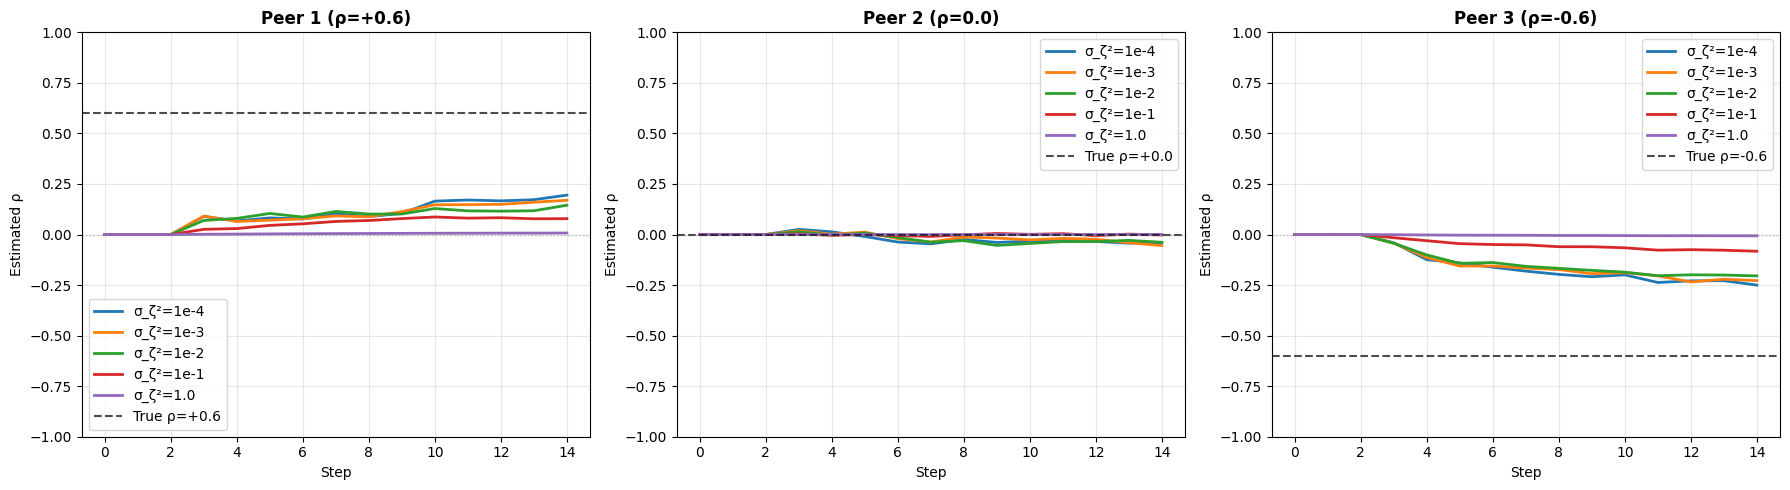

In [9]:
def plot_rho_trajectories_3peers(rho_hist_list, true_rho_values, exclude_baselines=True):
    """Plot estimated rho over time for each of the 3 peers"""
    
    condition_data = {}
    for entry in rho_hist_list:
        cond = entry["condition"]
        label = entry["condition_label"]
        
        if exclude_baselines and ("baseline" in cond):
            continue
            
        if cond not in condition_data:
            condition_data[cond] = {"label": label, "histories": []}
        condition_data[cond]["histories"].append(entry["rho_history"])
    
    mean_trajectories = {}
    for cond, data in condition_data.items():
        histories = np.stack(data["histories"], axis=0)
        mean_traj = np.mean(histories, axis=0)
        mean_trajectories[cond] = {"label": data["label"], "traj": mean_traj}
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    peer_names = ["Peer 1 (ρ=+0.6)", "Peer 2 (ρ=0.0)", "Peer 3 (ρ=-0.6)"]
    
    for peer_idx, (ax, peer_name, true_val) in enumerate(zip(axes, peer_names, true_rho_values)):
        for cond, data in mean_trajectories.items():
            rho_over_time = data["traj"][:, peer_idx + 1]
            ax.plot(rho_over_time, label=data["label"], linewidth=2)
        
        ax.axhline(true_val, linestyle='--', color='black', alpha=0.7, linewidth=1.5, 
                   label=f'True ρ={true_val:+.1f}')
        ax.axhline(0, linestyle=':', color='gray', alpha=0.5, linewidth=1)
        
        ax.set_title(peer_name, fontsize=12, fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("Estimated ρ")
        ax.set_ylim(-1.0, 1.0)
        ax.grid(alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.savefig("../sigma_zeta_rho_trajectories.png", dpi=150, bbox_inches='tight')
    plt.show()

true_rho_peers = rho_true[1:]  # Extract [0.6, 0.0, -0.6]
plot_rho_trajectories_3peers(rho_histories, true_rho_peers, exclude_baselines=True)

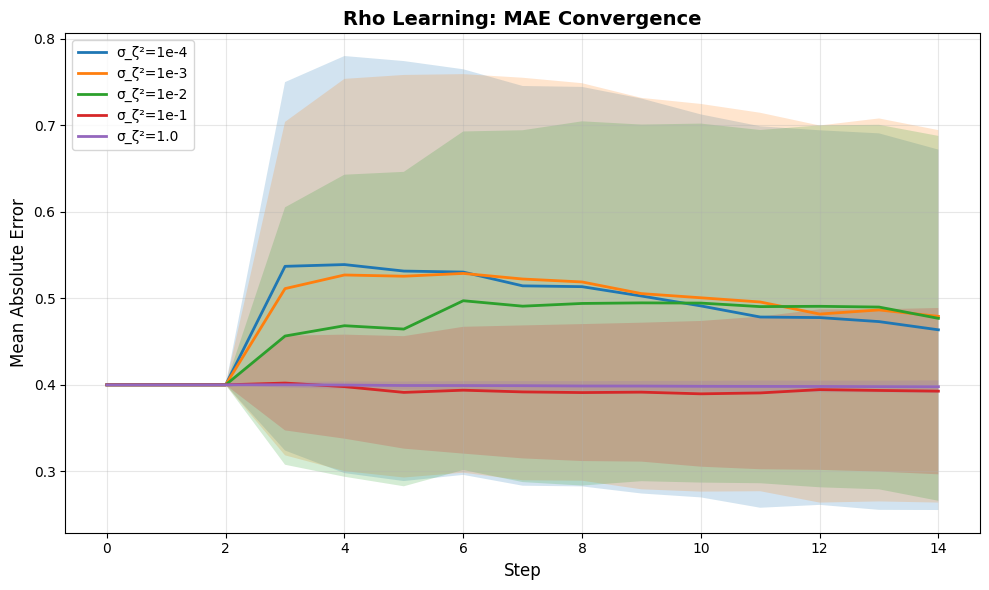

In [10]:
def plot_mae_convergence(rho_hist_list, true_rho_values, exclude_baselines=True):
    """Plot mean absolute error of rho estimates over time"""
    
    condition_data = {}
    for entry in rho_hist_list:
        cond = entry["condition"]
        label = entry["condition_label"]
        
        if exclude_baselines and ("baseline" in cond):
            continue
            
        if cond not in condition_data:
            condition_data[cond] = {"label": label, "histories": []}
        condition_data[cond]["histories"].append(entry["rho_history"])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for cond, data in condition_data.items():
        histories = np.stack(data["histories"], axis=0)
        estimates = histories[:, :, 1:]
        mae = np.abs(estimates - true_rho_values).mean(axis=2)
        mean_mae = mae.mean(axis=0)
        std_mae = mae.std(axis=0)
        
        steps = np.arange(len(mean_mae))
        ax.plot(steps, mean_mae, label=data["label"], linewidth=2)
        ax.fill_between(steps, mean_mae - std_mae, mean_mae + std_mae, alpha=0.2)
    
    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel("Mean Absolute Error", fontsize=12)
    ax.set_title("Rho Learning: MAE Convergence", fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig("../sigma_zeta_mae_convergence.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_mae_convergence(rho_histories, true_rho_peers, exclude_baselines=True)

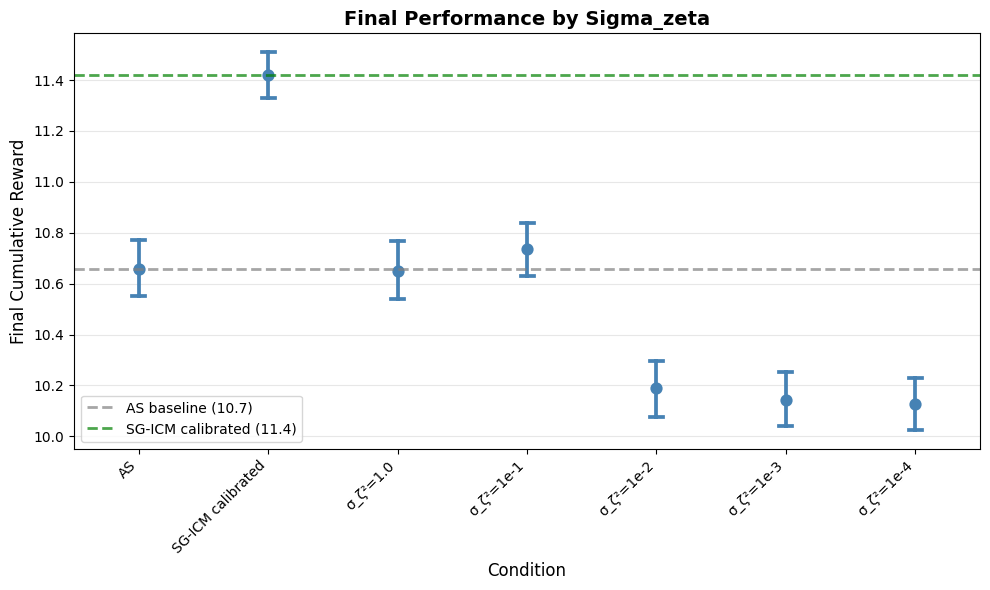

In [11]:
def _select_sg_agent(df):
    """Select only the SG-ICM agent (or first agent) from dataframe"""
    plot_df = df.copy()
    if "model_type" in plot_df.columns:
        sg = plot_df[(plot_df["model_type"] == "SG-ICM") | (plot_df["model_type"] == "SG")].copy()
        if not sg.empty:
            return sg
    if "AgentID" in plot_df.columns:
        min_id = plot_df["AgentID"].min()
        return plot_df[plot_df["AgentID"] == min_id].copy()
    return plot_df


def plot_final_performance_sigma_zeta(df):
    """Compare final cumulative rewards across sigma_zeta values"""
    
    plot_df = _select_sg_agent(df)
    
    final_step = plot_df.groupby(["seed", "condition_label"])["Step"].transform('max')
    final_df = plot_df[plot_df['Step'] == final_step].copy()
    
    label_order = sorted(final_df["condition_label"].unique())
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.pointplot(
        data=final_df,
        x="condition_label",
        y="cumulative_reward",
        order=label_order,
        errorbar=('ci', 95),
        linestyle='none',
        markers='o',
        ax=ax,
        capsize=0.1,
        color='steelblue',
    )
    
    # Add baseline reference lines
    as_mean = final_df.loc[final_df["condition_label"] == "AS", "cumulative_reward"].mean()
    calib_mean = final_df.loc[final_df["condition_label"] == "SG-ICM calibrated", "cumulative_reward"].mean()
    
    if pd.notna(as_mean):
        ax.axhline(as_mean, linestyle='--', color='gray', alpha=0.7, linewidth=2, 
                   label=f'AS baseline ({as_mean:.1f})')
    if pd.notna(calib_mean):
        ax.axhline(calib_mean, linestyle='--', color='green', alpha=0.7, linewidth=2, 
                   label=f'SG-ICM calibrated ({calib_mean:.1f})')
    
    ax.set_xlabel("Condition", fontsize=12)
    ax.set_ylabel("Final Cumulative Reward", fontsize=12)
    ax.set_title("Final Performance by Sigma_zeta", fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=10)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig("../sigma_zeta_final_performance.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_final_performance_sigma_zeta(results_df)

In [12]:
def compute_summary_stats(rho_hist_list, results_df, true_rho_values):
    """Compute final MAE and performance for each condition"""
    
    summary = []
    
    condition_data = {}
    for entry in rho_hist_list:
        cond = entry["condition"]
        label = entry["condition_label"]
        
        if cond not in condition_data:
            condition_data[cond] = {"label": label, "histories": [], "sigma_zeta": entry["sigma_zeta"]}
        condition_data[cond]["histories"].append(entry["rho_history"])
    
    for cond, data in condition_data.items():
        # Final MAE
        histories = np.stack(data["histories"], axis=0)
        final_estimates = histories[:, -1, 1:]
        final_mae = np.abs(final_estimates - true_rho_values).mean()
        
        # Per-peer final MAE
        peer1_mae = np.abs(final_estimates[:, 0] - true_rho_values[0]).mean()
        peer2_mae = np.abs(final_estimates[:, 1] - true_rho_values[1]).mean()
        peer3_mae = np.abs(final_estimates[:, 2] - true_rho_values[2]).mean()
        
        # Final performance
        sg_agent_df = _select_sg_agent(results_df[results_df["condition"] == cond])
        final_step = sg_agent_df.groupby("seed")["Step"].transform('max')
        final_rewards = sg_agent_df[sg_agent_df["Step"] == final_step]["cumulative_reward"]
        mean_reward = final_rewards.mean()
        std_reward = final_rewards.std()
        
        summary.append({
            "condition": cond,
            "label": data["label"],
            "sigma_zeta": data["sigma_zeta"],
            "final_mae": final_mae,
            "peer1_mae (ρ=+0.6)": peer1_mae,
            "peer2_mae (ρ=0.0)": peer2_mae,
            "peer3_mae (ρ=-0.6)": peer3_mae,
            "mean_reward": mean_reward,
            "std_reward": std_reward,
        })
    
    return pd.DataFrame(summary).sort_values("sigma_zeta")

summary_stats = compute_summary_stats(rho_histories, results_df, true_rho_peers)
print(summary_stats.to_string(index=False))

          condition             label  sigma_zeta  final_mae  peer1_mae (ρ=+0.6)  peer2_mae (ρ=0.0)  peer3_mae (ρ=-0.6)  mean_reward  std_reward
            sz_1e-4         σ_ζ²=1e-4      0.0001   0.463655            0.483680           0.461088            0.446196    10.128750    1.665706
baseline_calibrated SG-ICM calibrated      0.0001   0.000000            0.000000           0.000000            0.000000    11.419977    1.395287
   baseline_asocial                AS      0.0001   0.400000            0.600000           0.000000            0.600000    10.658356    1.816569
            sz_1e-3         σ_ζ²=1e-3      0.0010   0.479206            0.505799           0.463287            0.468533    10.142790    1.692332
            sz_1e-2         σ_ζ²=1e-2      0.0100   0.476908            0.531133           0.408016            0.491573    10.188556    1.723944
            sz_1e-1         σ_ζ²=1e-1      0.1000   0.392721            0.533242           0.113459            0.531461    10.7378